# Регрессия

Для лабороторной работы используются массив данных "Boston House Prices", его можно взять с сайта https://www.kaggle.com/datasets/fedesoriano/the-boston-houseprice-data/data

In [1]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score

from sklearn import metrics
from collections import Counter

In [2]:
# сразу напишем код функции, которая будет вычислять все нужные метрики

def Reg_Models_Evaluation_Metrics (model,X_train,y_train,X_test,y_test,y_pred):
    cv_score = cross_val_score(estimator = model, X = X_train, y = y_train, cv = 10)

    # Calculating Adjusted R-squared
    r2 = model.score(X_test, y_test)
    # Number of observations is the shape along axis 0
    n = X_test.shape[0]
    # Number of features (predictors, p) is the shape along axis 1
    p = X_test.shape[1]
    # Adjusted R-squared formula
    adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
    RMSE = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
    R2 = model.score(X_test, y_test)
    CV_R2 = cv_score.mean()

    print(f'RMSE:  {round(RMSE,4)}\n  R2: {round(R2,4)}\n Adjusted R2: {round(adjusted_r2, 4)}\n Cross Validated R2: {round(cv_score.mean(),4)}')
    return R2, adjusted_r2, CV_R2, RMSE

# Линейная регрессия

In [3]:
# импорт нужных библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes  # подключаем датасет из sklearn
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Присвоим переменной «url» ссылку на датасет:

url = '/content/boston.csv.xls'

# создаем лист с названием столбцов:


# используем Pandas read_csv():

dataset = pd.read_csv(url)

In [5]:
dataset.head(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222.0,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311.0,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311.0,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311.0,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311.0,15.2,386.71,17.10,18.9


Признаки по порядку:

CRIM - уровень преступности на душу населения по городам<br>
ZN - доля жилой земли, отведенной под участки более 25 000 кв. футов<br>
INDUS - доля площади под не-розничную торговлю (промышленность) в городе<br>
CHAS - фиктивная переменная реки Чарльз (1 - если рядом с рекой; 0 - иначе)<br>
NOX - концентрация оксидов азота (частей на 10 миллионов)<br>
RM - среднее количество комнат в жилье<br>
AGE - доля домов, построенных до 1940 года, находящихся в собственности<br>
DIS - взвешенное расстояние до пяти центров занятости Бостона<br>
RAD - индекс доступности к радиальным автомагистралям<br>
TAX - ставка налога на имущество в полном объеме на 10 000 долларов<br>
PTRATIO - соотношение учеников и учителей по городу<br>
B - результат уравнения B = 1000(Bk - 0,63)^2, где Bk - доля чернокожего населения по городу<br>
LSTAT - % населения с низким социальным статусом<br>
MEDV - медианная стоимость домов, занимаемых владельцами, в тысячах долларов [тыс. $]

In [6]:
# загружаем данные в pandas dataframe

dataset["DP"] = dataset['MEDV']
dataset

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,DP
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0,22.0


In [7]:
dataset.drop('MEDV', axis=1, inplace=True)

In [8]:
# подготавливаем датасет к обучению

X = dataset.drop(['DP'], axis=1)
y = dataset['DP']
print(f'X shape: {X.shape} | y shape: {y.shape} ')

X shape: (506, 13) | y shape: (506,) 


In [9]:
# делим датасет на трейн и тест

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=15)

In [10]:
from sklearn.linear_model import LinearRegression

# Create a linear regression model
modelLR = LinearRegression()

# Fit the model to the data
modelLR.fit(X_train, y_train)

# Predict the response for a new data point
y_pr_LR = modelLR.predict(X_test)

In [11]:
_ = Reg_Models_Evaluation_Metrics(modelLR, X_train, y_train, X_test, y_test, y_pr_LR)

RMSE:  4.8798
  R2: 0.6921
 Adjusted R2: 0.6466
 Cross Validated R2: 0.7074


неплохие метрики, R² > 0.6 считается хорошим результатом для социально-экономических данных

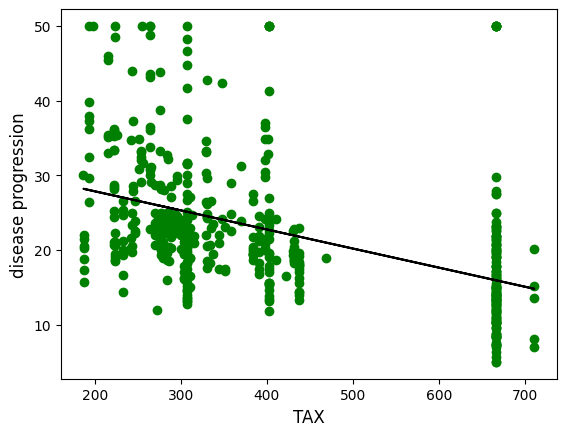

In [12]:
# попробуем отрисовать, как выглядит наша линейная регрессия

X2 = dataset['TAX'].values[:,np.newaxis]
# target data is array of shape (n,)
y2 = dataset['DP'].values


model2 = LinearRegression()
model2.fit(X2, y2)

plt.scatter(X2, y2,color='g')
plt.plot(X2, model2.predict(X2),color='k')
plt.ylabel('disease progression', size=12)
plt.xlabel('TAX', size=12)
plt.show()

# Полиномиальная регрессия

In [20]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(X)
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(poly_features, y, test_size=0.3, random_state=42)

In [21]:
# Create a linear regression model
modelPR = LinearRegression()

# Fit the model to the data
modelPR.fit(X_p_train, y_p_train)

# Predict the response for a new data point
y_pr_PR = modelPR.predict(X_p_test)

_ = Reg_Models_Evaluation_Metrics(modelPR, X_p_train, y_p_train, X_p_test, y_p_test, y_pr_PR)

RMSE:  5.0257
  R2: 0.661
 Adjusted R2: -0.089
 Cross Validated R2: 0.8162


R²: 0.661 - хороший результат для реальных данных

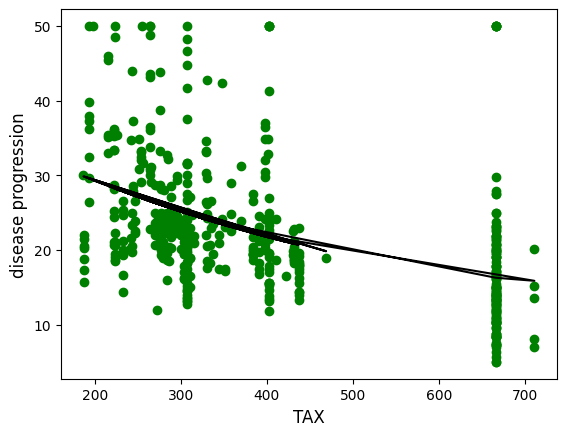

In [22]:
X2 = dataset['TAX'].values[:,np.newaxis]
# target data is array of shape (n,)
y2 = dataset['DP'].values

poly_features = poly.fit_transform(X2)

model2 = LinearRegression()
model2.fit(poly_features, y2)


plt.scatter(X2, y2,color='g')
plt.plot(X2, model2.predict(poly.fit_transform(X2)),color='k')
plt.ylabel('disease progression', size=12)
plt.xlabel('TAX', size=12)
plt.show()

# Регрессия дерева принятия решений

In [23]:
from sklearn.tree import DecisionTreeRegressor

# Create a stepwise regression model
modelDT = DecisionTreeRegressor()

# Fit the model to the data
modelDT.fit(X_train, y_train)

# Predict the response for a new data point
y_dt_pred = modelDT.predict(X_test)

In [24]:
_ = Reg_Models_Evaluation_Metrics(modelDT, X_train, y_train, X_test, y_test, y_dt_pred)

RMSE:  4.7603
  R2: 0.707
 Adjusted R2: 0.6637
 Cross Validated R2: 0.7457


Это хороший результат для реальных данных, R² выше, чем у полиномиальной регрессии (0.661)

# Регрессия случайного леса

In [25]:
from sklearn.ensemble import RandomForestRegressor

# Create a stepwise regression model
modelRF = RandomForestRegressor(n_estimators=100)

# Fit the model to the data
modelRF.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelRF.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelRF, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  3.4249
  R2: 0.8483
 Adjusted R2: 0.8259
 Cross Validated R2: 0.8729


Получился очень хороший результат

# Регрессия опорных векторов (SVR)

In [26]:
from sklearn.svm import SVR

# Create a support vector regression model
modelSVR = SVR(kernel='linear')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  4.3238
  R2: 0.7582
 Adjusted R2: 0.7225
 Cross Validated R2: 0.6728


Неплохие результаты, но хуже регрессии случайного леса

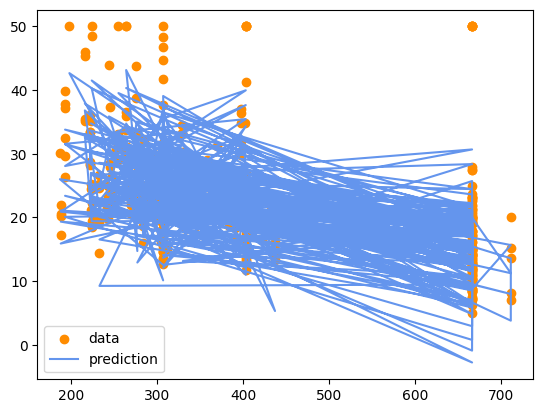

In [27]:
plt.scatter(X_train["TAX"], y_train, color='darkorange',
            label='data')
plt.plot(X_train["TAX"], modelSVR.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()

In [28]:
from sklearn.svm import SVR

# Create a support vector regression model. Полиномиальное ядро
modelSVR = SVR(kernel='poly')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  7.3097
  R2: 0.3091
 Adjusted R2: 0.207
 Cross Validated R2: 0.1818


SVR с полиномиальным ядром показывает худший результат из всех моделей

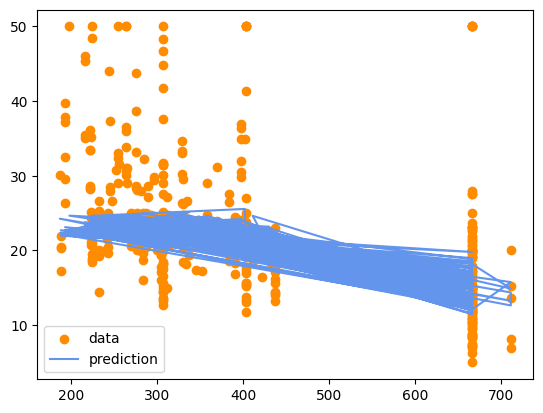

In [29]:
plt.scatter(X_train["TAX"], y_train, color='darkorange',
            label='data')
plt.plot(X_train["TAX"], modelSVR.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()

In [30]:
# Create a support vector regression model. Ядро - радиальная базисная функция
modelSVR = SVR(kernel='rbf')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  7.3156
  R2: 0.3079
 Adjusted R2: 0.2057
 Cross Validated R2: 0.1849


SVR с RBF ядром показывает такой же плохой результат, как и полиномиальное ядро

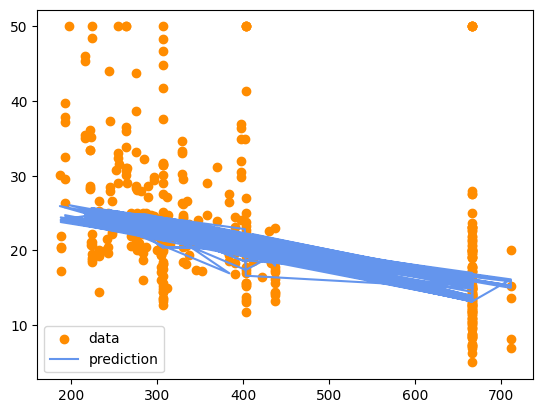

In [31]:
plt.scatter(X_train["TAX"], y_train, color='darkorange',
            label='data')
plt.plot(X_train["TAX"], modelSVR.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()

# Регрессия ElasticNet

In [32]:
from sklearn.linear_model import ElasticNet

# Create an elastic net regression model
modelEN = ElasticNet(alpha=0.1, l1_ratio=0.8)

# Fit the model to the data
modelEN.fit(X_train, y_train)

# Predict the response for a new data point
y_en_pred = modelEN.predict(X_test)

_ = Reg_Models_Evaluation_Metrics(modelEN, X_train, y_train, X_test, y_test, y_en_pred)

RMSE:  4.7558
  R2: 0.7075
 Adjusted R2: 0.6643
 Cross Validated R2: 0.6918


хороший результат, практически идентичный регрессии дерева принятия решений

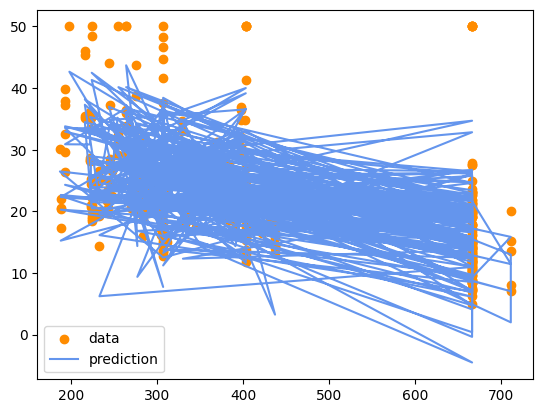

In [33]:
plt.scatter(X_train["TAX"], y_train, color='darkorange',
            label='data')
plt.plot(X_train["TAX"], modelEN.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()

в итоге, самый лучший результат получился у **регрессии случайного леса**